# G · 타자 정보 확장

**동기**: A~F까지의 파생 피처는 거의 전부 **투수 쪽**이었다. CSW는 투수가 던지고 **타자가 판단**해서 나오는 결과이므로,
타자 정보를 제대로 넣지 않은 것이 남은 구멍이었다.

## 타자 피처 구성 (총 73개)
| 그룹 | 개수 | 내용 |
|---|---|---|
| `batter_te` | 1 | 타자가 허용한 CSW율 (전 기간 expanding + 수축) |
| `batter_scout` (E에서 추가) | 30 | 구종 카테고리(fb/br/off)별 상대빈도·헛스윙률·콜스트라이크허용률·chase률·스윙률 (+표본수) |
| **`batter_hist` (G에서 신규)** | **42** | 4지표(허용CSW·헛스윙·콜스트라이크·chase) × 4창(시즌누적·전기간·지난시즌·최근200구) + **투수 좌우 스플릿** |

**설계 원칙**
- 전부 `shift(1)` 시간안전 — 현재 투구 결과는 절대 미포함
- 지표별 **분모 분리**(헛스윙=스윙 수, 콜스트라이크=지켜본 수, chase=존밖 수) + 지표별 **Beta-Binomial 수축** + **표본수 컬럼**
- 메모리 제약(3GB)으로 전처리를 2단계로 분리 (`prep_features.py` → `prep_g.py`)

**핵심 질문**: 타자 정보를 넣으면 정말 좋아지는가? → **타자 피처를 전부 빼고/넣고 격리 측정**한다.

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
V3 = Path("out/v3")
G = json.load(open(V3/"G_batter.json"))
meta = json.load(open("cache/meta_g.json"))
BASE = G["baselines"]
print("피처: 전체", len(meta["g_feats"]), "| 타자 관련", len(meta["batter_all"]),
      "(scout 30 + hist", len(meta["batter_hist"]), "+ te 1)")
print("baseline LogLoss:", {k: v["logloss"] for k, v in BASE.items()})

피처: 전체 299 | 타자 관련 73 (scout 30 + hist 42 + te 1)
baseline LogLoss: {'league_mean': 0.5957, 'count_only': 0.579, 'pitcher_te': 0.5947}


## 1. 타자 정보의 순기여 — 격리 측정
타자 관련 73개를 전부 제거한 모델과 비교한다.

기존 타자 피처 기여: -0.00200 LogLoss
확장까지 전체 기여 : -0.00220 LogLoss  (음수 = 개선)


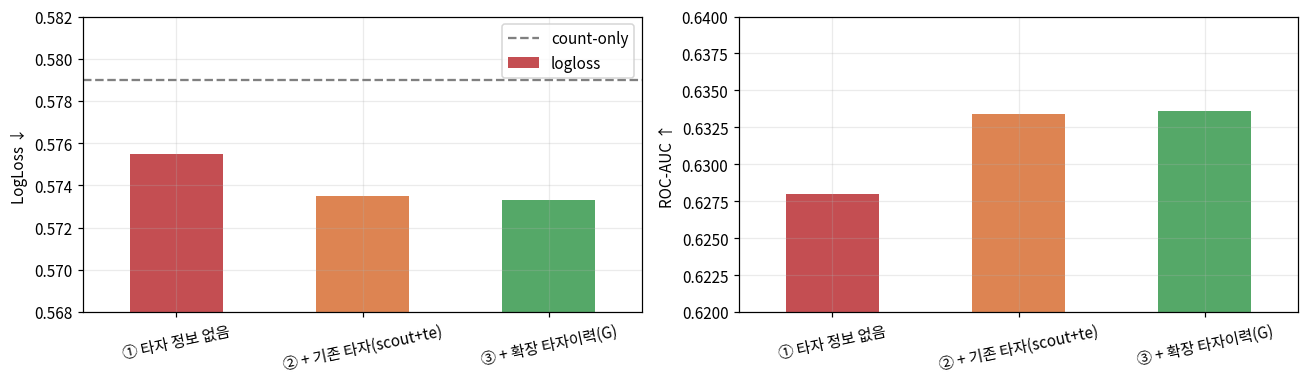

,logloss,roc_auc,pr_auc,ece,n_feats
① 타자 정보 없음,0.5755,0.6280,0.3875,0.0078,226.0
② + 기존 타자(scout+te),0.5735,0.6334,0.3933,0.0059,257.0
③ + 확장 타자이력(G),0.5733,0.6336,0.3936,0.0037,299.0


In [2]:
rows = {"① 타자 정보 없음": G["1_no_batter"], "② + 기존 타자(scout+te)": G["2_batter_basic"],
        "③ + 확장 타자이력(G)": G["3_batter_full"]}
t = pd.DataFrame(rows).T[["logloss","roc_auc","pr_auc","ece","n_feats"]]
print(f"기존 타자 피처 기여: {G['delta_batter_basic']:+.5f} LogLoss")
print(f"확장까지 전체 기여 : {G['delta_batter_full']:+.5f} LogLoss  (음수 = 개선)")
fig, ax = plt.subplots(1,2, figsize=(12,3.6))
t["logloss"].plot.bar(ax=ax[0], color=["#C44E52","#DD8452","#55A868"])
ax[0].axhline(BASE["count_only"]["logloss"], ls="--", c="gray", label="count-only")
ax[0].set_ylim(0.568, 0.582); ax[0].set_ylabel("LogLoss ↓"); ax[0].legend(); plt.setp(ax[0].get_xticklabels(), rotation=12)
t["roc_auc"].plot.bar(ax=ax[1], color=["#C44E52","#DD8452","#55A868"]); ax[1].set_ylim(0.62,0.64)
ax[1].set_ylabel("ROC-AUC ↑"); plt.setp(ax[1].get_xticklabels(), rotation=12)
plt.tight_layout(); plt.show()
t

**결과**: 타자 정보를 넣으면 확실히 좋아진다 (LogLoss −0.0022, AUC +0.006).
다만 대부분의 이득은 **기존 스카우팅 피처**에서 나오고, G의 확장 42개가 추가로 주는 몫은 작다(−0.0002).
E의 누적 ablation에서 기여가 안 보였던 이유는 **누적 방식이라 다른 피처와 섞여 상쇄**됐기 때문 — 격리해야 보인다.

## 2. 타자 피처가 모델에서 차지하는 비중

타자 피처 중요도 점유율: 0.311 (전체 중요도 합 대비)


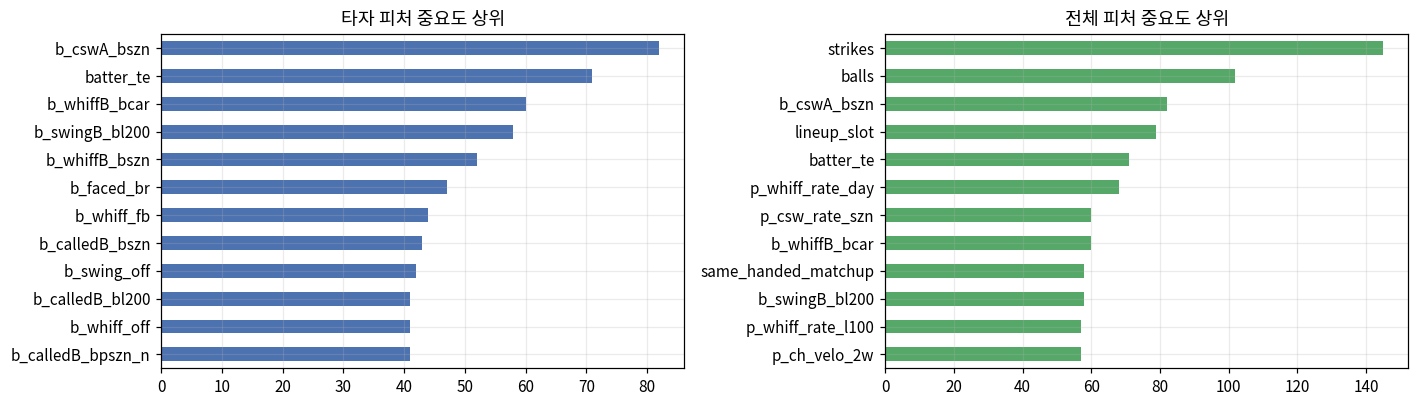

In [3]:
print("타자 피처 중요도 점유율:", G["batter_importance_share"], "(전체 중요도 합 대비)")
fig, ax = plt.subplots(1,2, figsize=(13,3.8))
pd.Series(G["top_batter_features"]).iloc[::-1].plot.barh(ax=ax[0], color="#4C72B0")
ax[0].set_title("타자 피처 중요도 상위")
pd.Series(G["top_overall"]).iloc[::-1].plot.barh(ax=ax[1], color="#55A868")
ax[1].set_title("전체 피처 중요도 상위")
plt.tight_layout(); plt.show()

## 3. 최종 — 확장 타자 + CS/W 분해 결합

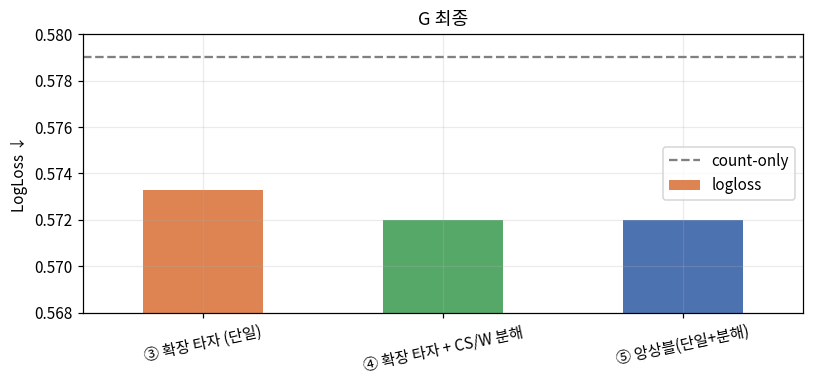

,logloss,roc_auc,pr_auc,ece
③ 확장 타자 (단일),0.5733,0.6336,0.3936,0.0037
④ 확장 타자 + CS/W 분해,0.5720,0.6371,0.3997,0.0073
⑤ 앙상블(단일+분해),0.5720,0.6370,0.3991,0.0049


In [4]:
rows2 = {"③ 확장 타자 (단일)": G["3_batter_full"],
         "④ 확장 타자 + CS/W 분해": G["4_batter_full_decomposed"],
         "⑤ 앙상블(단일+분해)": G["5_ensemble"]}
t2 = pd.DataFrame(rows2).T[["logloss","roc_auc","pr_auc","ece"]]
fig, ax = plt.subplots(figsize=(7.5,3.6))
t2["logloss"].plot.bar(ax=ax, color=["#DD8452","#55A868","#4C72B0"])
ax.axhline(BASE["count_only"]["logloss"], ls="--", c="gray", label="count-only")
ax.set_ylim(0.568, 0.580); ax.set_ylabel("LogLoss ↓"); ax.legend(); plt.xticks(rotation=12)
plt.title("G 최종"); plt.tight_layout(); plt.show()
t2

## 4. 전체 라운드 누적 성과

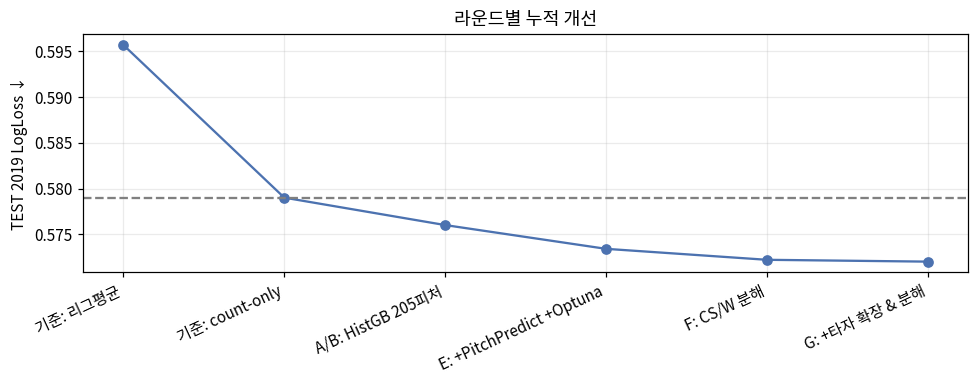

누적 개선: 0.5760 → 0.5720 (-0.0040)
count-only 대비: -0.0070


In [5]:
hist = {"기준: 리그평균": 0.5957, "기준: count-only": 0.5790,
        "A/B: HistGB 205피처": 0.5760, "E: +PitchPredict +Optuna": 0.5734,
        "F: CS/W 분해": 0.5722, "G: +타자 확장 & 분해": G["4_batter_full_decomposed"]["logloss"]}
s = pd.Series(hist)
ax = s.plot(marker="o", figsize=(9,3.6), color="#4C72B0")
ax.axhline(0.5790, ls="--", c="gray"); ax.set_ylabel("TEST 2019 LogLoss ↓")
plt.xticks(range(len(s)), s.index, rotation=25, ha="right"); plt.title("라운드별 누적 개선")
plt.tight_layout(); plt.show()
print(f"누적 개선: 0.5760 → {s.iloc[-1]:.4f} ({s.iloc[-1]-0.5760:+.4f})")
print(f"count-only 대비: {s.iloc[-1]-0.5790:+.4f}")

## 5. 결론
- **타자 정보는 유효하다** — 격리 측정 시 LogLoss −0.0022, AUC +0.006. 모델 중요도의 **31%** 를 타자 피처가 차지한다.
- 이득의 대부분은 **구종 카테고리별 스카우팅**(chase/whiff/콜스트라이크 허용 성향)에서 나온다.
- **최고 성능: 0.5720** (확장 타자 + CS/W 분해). count-only 대비 −0.0070.
- 여전히 절대 개선폭은 작다 — **D의 천장 진단**(투구 위치를 모르면 AUC 0.63~0.64 부근이 상한)과 일관된다.